# Classificação de Dígitos Manuscritos com Machine Learning

## Objetivo

Desenvolver e comparar modelos de classificação capazes de reconhecer dígitos manuscritos do dataset **MNIST**. A análise considera o desempenho preditivo, o custo computacional e a robustez dos modelos em diferentes cenários.

## Etapas de desenvolvimento

### 1. Carregamento e análise exploratória dos dados

- Carregar o dataset MNIST.
- Verificar o formato dos dados, as classes e a quantidade de amostras.
- Avaliar o balanceamento entre as classes.
- Visualizar exemplos dos dígitos.

### 2. Preparação dos dados

- Separar os dados em conjuntos de treino, validação e teste.
- Manter a proporção das classes durante a divisão.
- Normalizar os valores dos pixels para o intervalo entre 0 e 1.

### 3. Treinamento dos modelos

Treinar e comparar os seguintes modelos:

- Random Forest;
- Regressão Logística;
- Rede Neural MLP.

Também serão definidos e ajustados hiperparâmetros para buscar melhores resultados.

### 4. Avaliação dos modelos

Comparar os modelos utilizando:

- Acurácia;
- Precisão;
- Recall;
- F1-Score;
- Matrizes de confusão;
- Tempo de treinamento.

### 5. Teste de robustez

- Verificar o comportamento dos modelos quando determinados dígitos não aparecem no treinamento.
- Testar o modelo selecionado com imagens de dígitos escritos à mão.
- Processar as imagens externas utilizando OpenCV.

## Resultado esperado

Ao final, selecionar o modelo com o melhor equilíbrio entre desempenho, tempo de treinamento e capacidade de generalização.

Fase 1: Carregamento e Análise Exploratória de Dados (EDA)

Dataset baixado com sucesso!

=== DIMENSIONALIDADE DOS MATRIZES ===
Matriz de Características (X): (70000, 784) (Imagens x Pixels)
Matriz de Rótulos (y): (70000,)



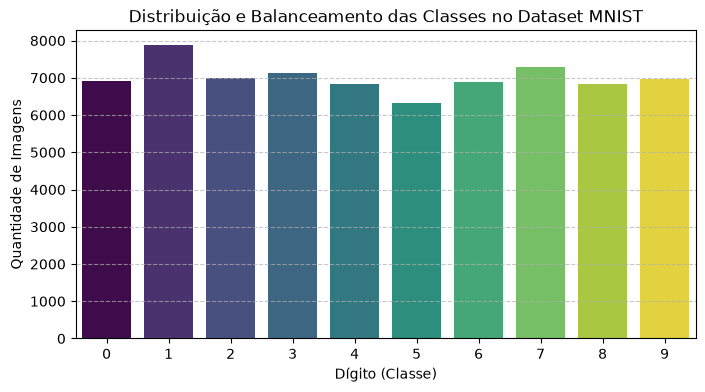

=== GRADE VISUAL: EXEMPLOS DE DÍGITOS ===


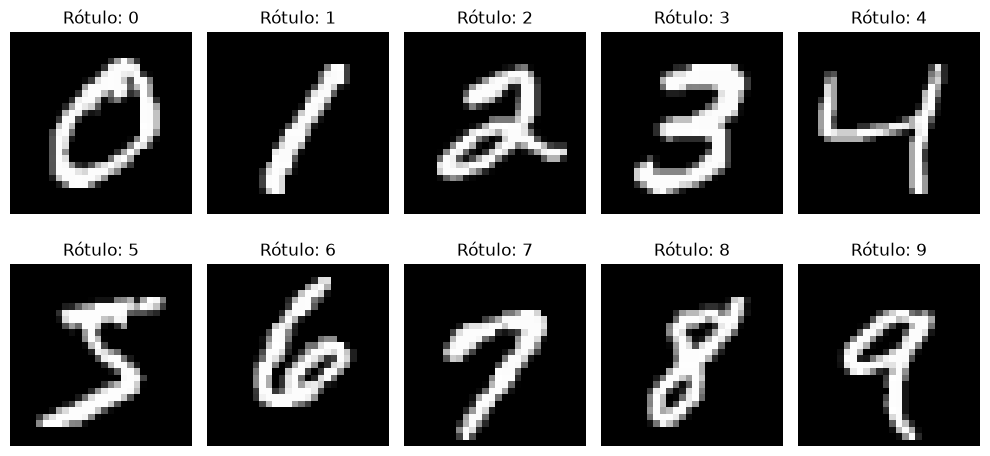

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

mnist = fetch_openml(
    'mnist_784',
    version=1,
    as_frame=False,
    parser='auto',
    data_home='./data'
 )

print("Dataset baixado com sucesso!")

# Separando recursos (X) e rótulos (y)
X, y = mnist["data"], mnist["target"]
y = y.astype(np.uint8)

# 1. EXIBIR DIMENSIONALIDADE
print("\n=== DIMENSIONALIDADE DOS MATRIZES ===")
print(f"Matriz de Características (X): {X.shape} (Imagens x Pixels)")
print(f"Matriz de Rótulos (y): {y.shape}\n")

# 2. COMPROVAR O BALANCEAMENTO DAS CLASSES
classes, contagens = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 4))
sns.barplot(
    x=classes,
    y=contagens,
    hue=classes,
    palette="viridis",
    legend=False
)
plt.title("Distribuição e Balanceamento das Classes no Dataset MNIST")
plt.xlabel("Dígito (Classe)")
plt.ylabel("Quantidade de Imagens")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# 3. GERAR GRADE VISUAL (Mínimo 2x5)
print("=== GRADE VISUAL: EXEMPLOS DE DÍGITOS ===")
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
axes = axes.ravel()

for i in range(10):
    indice = np.where(y == i)
    imagem_digito = X[indice][0].reshape(28, 28) # Pega o primeiro exemplo de cada dígito
    axes[i].imshow(imagem_digito, cmap="gray")
    axes[i].set_title(f"Rótulo: {i}", fontsize=12)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Fase 2: Preparação dos Dados

A normalização dos pixels para a escala [0, 1] é fundamental para algoritimos de Machine Learning porque garante que todos os recursos (features) tenham o mesmo peso inicial. Para modelos lineares e baseados em distâncias métricas, dados não normalizados causam instabilidade no gradiente, fazendo com que o modelo demore muito mais para convergir (encontrar o resultado ideal) ou at´e mesmo falhe em convergir.

In [2]:
# Normalizando os valores dos pixels para o intervalo [0, 1]
x_scaled = X / 255.0  

X_train_val, X_test, y_train_val, y_test = train_test_split(
    x_scaled, 
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, 
    y_train_val,
    test_size=0.125,
    stratify=y_train_val,
    random_state=42
)

display("\n=== DIVISÃO DO DATASET ===")
display(f"Treinamento: {X_train.shape[0]} amostras")
display(f"Validação: {X_val.shape[0]} amostras")
display(f"Teste: {X_test.shape[0]} amostras")

'\n=== DIVISÃO DO DATASET ==='

'Treinamento: 49000 amostras'

'Validação: 7000 amostras'

'Teste: 14000 amostras'

Fase 3: Treinamento dos Modelos